# SmartHandover — Day 5: Text Ensemble (RoBERTa + GoEmotions + VADER)

Combina os 3 classificadores de texto com weighted average.

**Abordagem:**
1. Grid search dos pesos (alpha, beta, gamma) no **validation set**
2. Avaliar com os melhores pesos no **test set**
3. Comparar ensemble vs modelos individuais

In [1]:
#%pip install pandas scikit-learn numpy matplotlib --quiet

In [2]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.classifiers.ensemble import (
    TextEnsembleClassifier, vader_to_probs, goemo_row_to_probs,
    TARGET_LABELS, TARGET_LABEL2ID,
)
from src.evaluation.metrics import compute_metrics, print_metrics

## 1. Verificar CSVs necessarios

In [3]:
csvs = {
    "RoBERTa (test)": "../data/processed/roberta_predictions.csv",
    "RoBERTa (val)": "../data/processed/roberta_val_predictions.csv",
    "GoEmotions": "../data/processed/goemo_predictions.csv",
    "VADER": "../data/processed/vader_predictions.csv",
}
for name, path in csvs.items():
    exists = os.path.exists(path)
    size = os.path.getsize(path) if exists else 0
    status = f"{size/1024:.0f} KB" if exists else "MISSING"
    print(f"  {name:<20s} {status:>10s}  {'OK' if exists else 'ERRO'}")

  RoBERTa (test)           365 KB  OK
  RoBERTa (val)            149 KB  OK
  GoEmotions              2414 KB  OK
  VADER                    981 KB  OK


## 2. Funcao de alinhamento

In [4]:
def load_and_prepare(roberta_path):
    """Carrega os 3 CSVs e alinha por (text, true_label)."""
    roberta_df = pd.read_csv(roberta_path)
    goemo_df = pd.read_csv("../data/processed/goemo_predictions.csv")
    vader_df = pd.read_csv("../data/processed/vader_predictions.csv")

    roberta_df["_order"] = range(len(roberta_df))

    goemo_prob_cols = [c for c in goemo_df.columns if c.startswith("goemo_")]
    goemo_sub = goemo_df[["text", "true_label"] + goemo_prob_cols]
    vader_sub = vader_df[["text", "true_label", "vader_compound"]]

    merged = roberta_df.merge(goemo_sub, on=["text", "true_label"], how="inner")
    merged = merged.merge(vader_sub, on=["text", "true_label"], how="inner")
    merged = merged.drop_duplicates(subset="_order").sort_values("_order").reset_index(drop=True)

    print(f"  Amostras alinhadas: {len(merged)}/{len(roberta_df)}")

    rob_prob_cols = sorted([c for c in roberta_df.columns if c.startswith("prob_")])
    roberta_probs = merged[rob_prob_cols].values
    goemo_probs = np.array([goemo_row_to_probs(row) for _, row in merged.iterrows()])
    vader_probs = np.array([vader_to_probs(row["vader_compound"]) for _, row in merged.iterrows()])
    true_labels = [TARGET_LABEL2ID[l] for l in merged["true_label"]]

    return roberta_probs, goemo_probs, vader_probs, true_labels

## 3. Grid search no Validation Set

In [5]:
print("A carregar validation set...")
val_rob, val_goemo, val_vader, val_labels = load_and_prepare(
    "../data/processed/roberta_val_predictions.csv"
)

ensemble = TextEnsembleClassifier()
best = ensemble.find_best_weights(val_rob, val_goemo, val_vader, val_labels)

print(f"\nMelhores pesos:")
print(f"  alpha (RoBERTa) = {best['alpha']}")
print(f"  beta  (GoEmo)   = {best['beta']}")
print(f"  gamma (VADER)   = {best['gamma']}")
print(f"  Val W-F1        = {best['weighted_f1']:.4f}")

A carregar validation set...
  Amostras alinhadas: 958/958

Melhores pesos:
  alpha (RoBERTa) = 0.3
  beta  (GoEmo)   = 0.3
  gamma (VADER)   = 0.4
  Val W-F1        = 0.5120


## 4. Avaliar no Test Set

In [6]:
print("A carregar test set...")
test_rob, test_goemo, test_vader, test_labels = load_and_prepare(
    "../data/processed/roberta_predictions.csv"
)

# Aplicar pesos do grid search
combined = (ensemble.alpha * test_rob +
            ensemble.beta * test_goemo +
            ensemble.gamma * test_vader)
ensemble_preds = np.argmax(combined, axis=-1)

metrics = compute_metrics(test_labels, ensemble_preds, target_names=TARGET_LABELS)
print_metrics(metrics)

A carregar test set...
  Amostras alinhadas: 2329/2329

  Accuracy     : 0.4989
  Weighted F1  : 0.5270
  Macro F1     : 0.3880
  Frustration R: 0.1600  << KEY METRIC

  Class             Prec    Rec     F1  Support
  -------------------------------------------
  anger            0.553  0.404  0.467      413
  frustration      0.131  0.160  0.144       50 <<
  sadness          0.090  0.216  0.127      208
  neutral          0.673  0.552  0.606     1256
  satisfaction     0.574  0.619  0.596      402

  Confusion Matrix (rows=true, cols=pred):
            anger  frust  sadne  neutr  satis
    anger     167     11     53    139     43
    frust       7      8     12     20      3
    sadne      30     13     45    100     20
    neutr      63     21    360    693    119
    satis      35      8     32     78    249


## 5. Tabela comparativa final

In [7]:
all_results = [("Text Ensemble", metrics["weighted_f1"], metrics["macro_f1"],
                metrics["frustration_recall"])]

for name, probs in [("RoBERTa (fine-tuned)", test_rob),
                    ("GoEmotions", test_goemo),
                    ("VADER", test_vader)]:
    preds = np.argmax(probs, axis=-1)
    m = compute_metrics(test_labels, preds.tolist(), target_names=TARGET_LABELS)
    all_results.append((name, m["weighted_f1"], m["macro_f1"], m["frustration_recall"]))

# Adicionar SpeechBrain se existir
sb_path = "../data/processed/speechbrain_predictions.csv"
if os.path.exists(sb_path):
    sb_df = pd.read_csv(sb_path)
    yt = [TARGET_LABEL2ID[l] for l in sb_df["true_label"]]
    yp = [TARGET_LABEL2ID[l] for l in sb_df["predicted_class"]]
    m = compute_metrics(yt, yp, target_names=TARGET_LABELS)
    all_results.append(("SpeechBrain (audio)", m["weighted_f1"], m["macro_f1"], m["frustration_recall"]))

comparison = pd.DataFrame(all_results, columns=["Model", "W-F1", "M-F1", "Frust Recall"])
comparison = comparison.sort_values("W-F1", ascending=False).reset_index(drop=True)
comparison.style.format({"W-F1": "{:.4f}", "M-F1": "{:.4f}", "Frust Recall": "{:.4f}"})

,Model,W-F1,M-F1,Frust Recall
0,GoEmotions,0.5467,0.3774,0.3600
1,Text Ensemble,0.5270,0.3880,0.1600
2,VADER,0.4168,0.2553,0.0000
3,SpeechBrain (audio),0.3994,0.2581,0.0000
4,RoBERTa (fine-tuned),0.2631,0.2929,0.1600


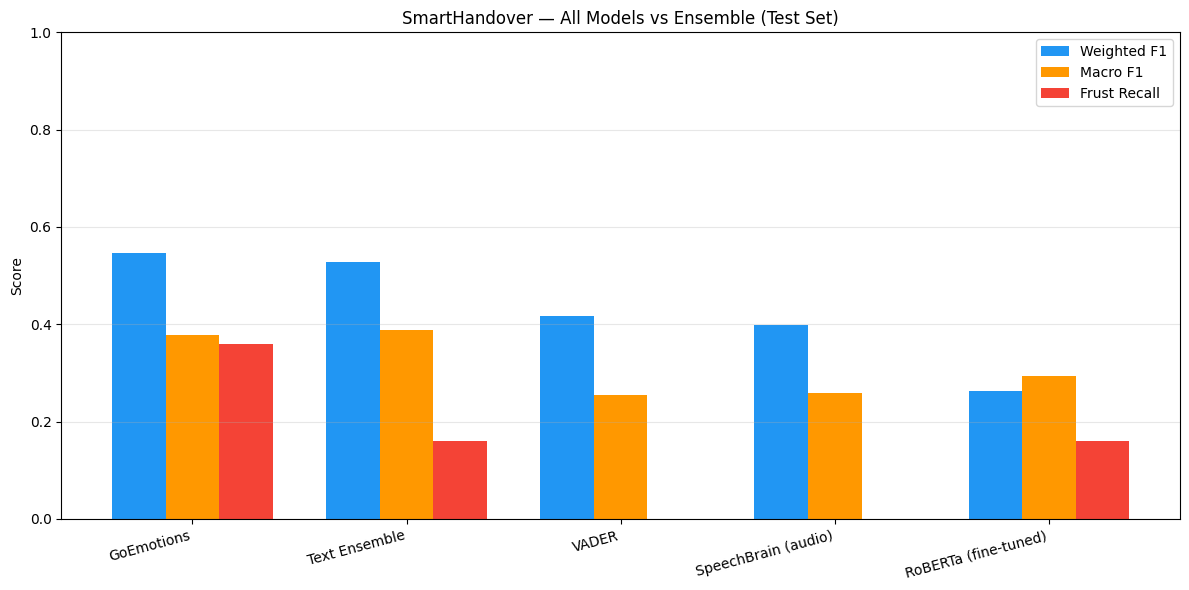

Guardado em data/processed/ensemble_comparison.png


In [8]:
# Grafico de barras comparativo
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(comparison))
width = 0.25

bars1 = ax.bar([i - width for i in x], comparison["W-F1"], width, label="Weighted F1", color="#2196F3")
bars2 = ax.bar(x, comparison["M-F1"], width, label="Macro F1", color="#FF9800")
bars3 = ax.bar([i + width for i in x], comparison["Frust Recall"], width, label="Frust Recall", color="#F44336")

ax.set_xticks(x)
ax.set_xticklabels(comparison["Model"], rotation=15, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.0)
ax.set_title("SmartHandover — All Models vs Ensemble (Test Set)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("../data/processed/ensemble_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado em data/processed/ensemble_comparison.png")

## 6. Peso de cada modelo no ensemble

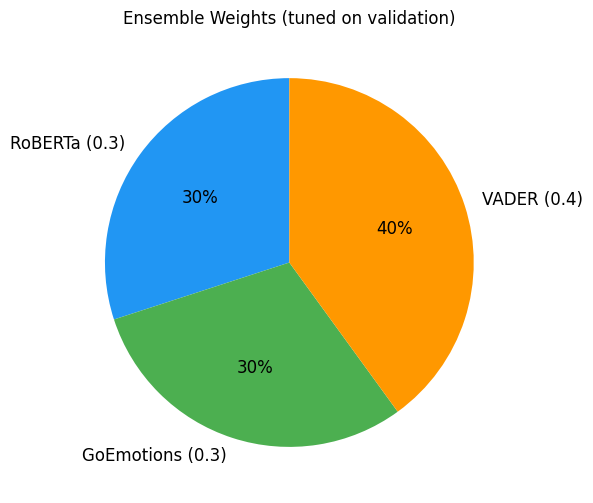

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
weights = [ensemble.alpha, ensemble.beta, ensemble.gamma]
labels = [f"RoBERTa ({ensemble.alpha})", f"GoEmotions ({ensemble.beta})", f"VADER ({ensemble.gamma})"]
colors = ["#2196F3", "#4CAF50", "#FF9800"]
ax.pie(weights, labels=labels, colors=colors, autopct="%1.0f%%", startangle=90, textprops={"fontsize": 12})
ax.set_title("Ensemble Weights (tuned on validation)")
plt.tight_layout()
plt.show()